In [1]:
import sys
sys.path.append("../ext/equi-rl-for-pomdps")
from rgbd_sym.api import make_env
import argparse
import numpy as np
from rgbd_sym.tool.plt import use_backend, plot_img, plot_traj
import matplotlib.pyplot as plt
from rgbd_sym.tool.sym import local_sym_step, get_sym_params, generate_sym2, actions2Ts
from rgbd_sym.tool.depth import get_intrinsic_matrix, projection_matrix_to_K
import time
from copy import deepcopy

size = 84




Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


robot id None
K [[59.98221231  0.         42.        ]
 [ 0.         59.98221231 42.        ]
 [ 0.          0.          1.        ]]


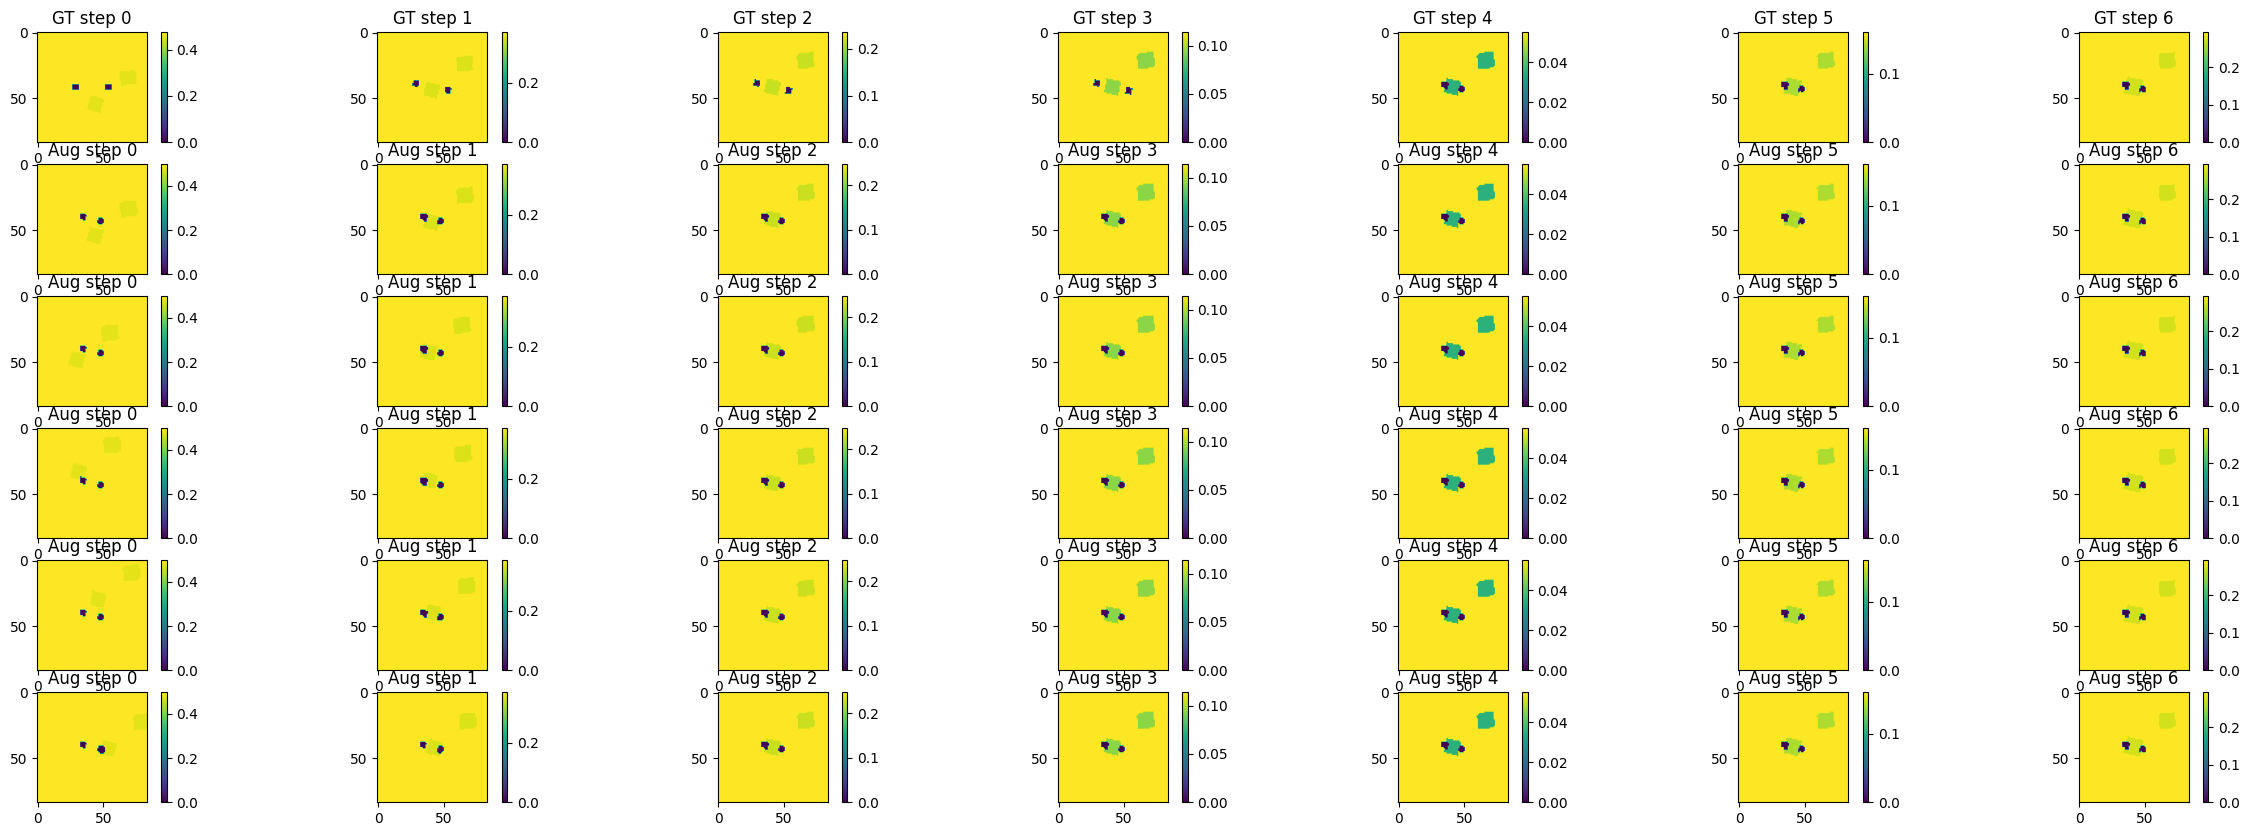

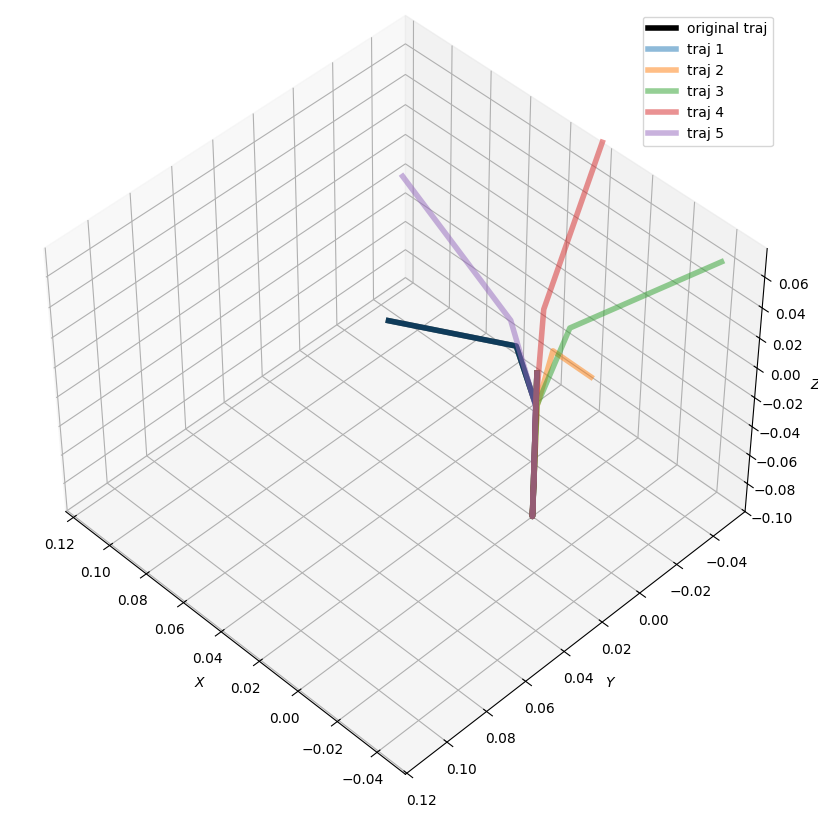

In [5]:
env, env_config = make_env(tags=['block_pick'], seed=0)
obs = env.reset()
# obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
print("K", K)

args = env.sym_args
# generate ground truth trajectory
origin_actions = []
obss_origin = [obs]
done = False
while not done:
    action = env.get_oracle_action()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    obss_origin.append(obs)
args['traj_nums']   = 5 
args['radius_ratio'] = 1
args['height_ratio'] = 1
args['screw_angle'] =  0
    
new_obss, new_actionss = generate_sym2(obss_origin, origin_actions, 
              **args)


imgss = []
imgss.append([{"image": v['image'][0,:,:], "title": f"GT step {i}"} for i, v in enumerate(obss_origin)])
for new_obs in new_obss:
    imgss.append([{"image": v['image'][0,:,:], "title": f"Aug step {i}"} for i, v in enumerate(new_obs)])
plt.rcParams['figure.figsize'] = [30, 10]
plot_img(imgss)



points_mats = []
trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
points_mats = []
pc_mat = {}
pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat["linewidth"] = 4
pc_mat["alpha"] = 1
pc_mat["label"] = f"original traj"
pc_mat["color"] = "k"
points_mats.append(pc_mat)

for i, new_actions in enumerate(new_actionss):
    new_trajTs = actions2Ts(
    [-a for a in reversed(new_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
    )
    pc_mat = {}
    pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in new_trajTs])
    pc_mat["linewidth"] = 4
    pc_mat["alpha"] = 0.5
    pc_mat["label"] = f"traj {i+1}"
    points_mats.append(pc_mat)   
plot_traj(points_mats, elev=45, azim=135, roll=0)

robot id None
K [[59.98221231  0.         42.        ]
 [ 0.         59.98221231 42.        ]
 [ 0.          0.          1.        ]]


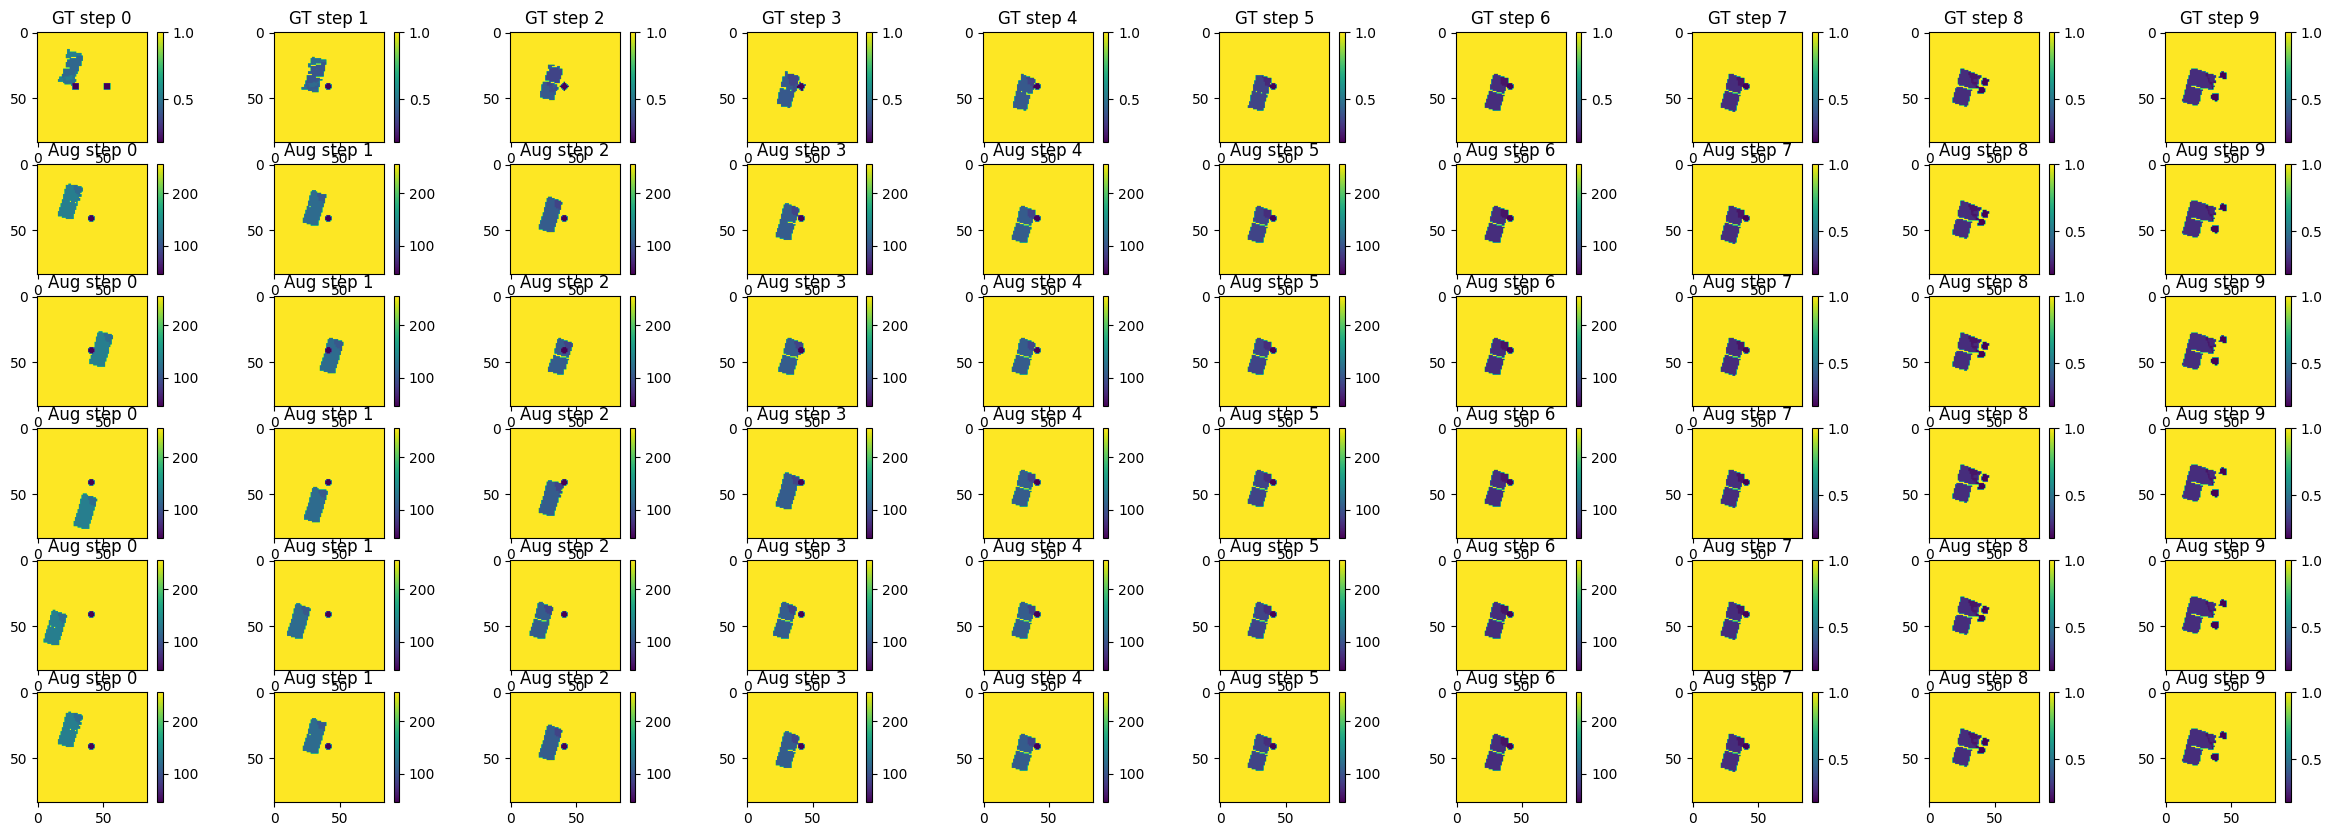

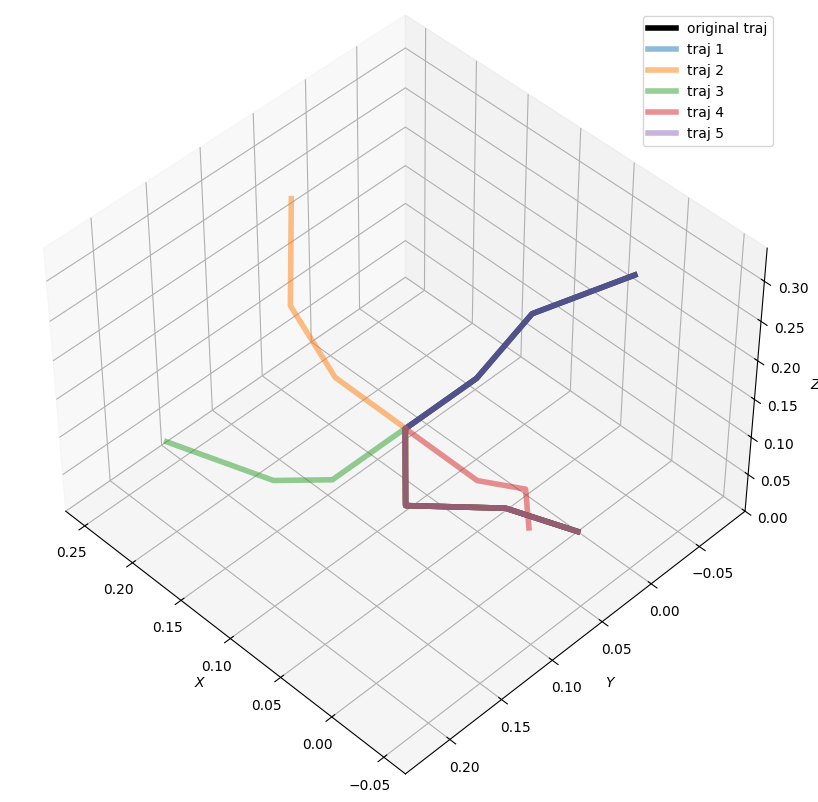

In [3]:
env, env_config = make_env(tags=['drawer_open'], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
print("K", K)

args = env.sym_args
# generate ground truth trajectory
origin_actions = []
obss_origin = [obs]
done = False
while not done:
    action = env.get_oracle_action()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    obss_origin.append(obs)
args['traj_nums']   = 5 
args['radius_ratio'] = 1
args['height_ratio'] = 1
args['screw_angle'] =  0
    
new_obss, new_actionss = generate_sym2(obss_origin, origin_actions, 
              **args)


imgss = []
imgss.append([{"image": v['image'][0,:,:], "title": f"GT step {i}"} for i, v in enumerate(obss_origin)])
for new_obs in new_obss:
    imgss.append([{"image": v['image'][0,:,:], "title": f"Aug step {i}"} for i, v in enumerate(new_obs)])
plt.rcParams['figure.figsize'] = [30, 10]
plot_img(imgss)



points_mats = []
trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
points_mats = []
pc_mat = {}
pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat["linewidth"] = 4
pc_mat["alpha"] = 1
pc_mat["label"] = f"original traj"
pc_mat["color"] = "k"
points_mats.append(pc_mat)

for i, new_actions in enumerate(new_actionss):
    new_trajTs = actions2Ts(
    [-a for a in reversed(new_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
    )
    pc_mat = {}
    pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in new_trajTs])
    pc_mat["linewidth"] = 4
    pc_mat["alpha"] = 0.5
    pc_mat["label"] = f"traj {i+1}"
    points_mats.append(pc_mat)   
plot_traj(points_mats, elev=45, azim=135, roll=0)